# Artificial Neural Networks and Deep Learning

## Homework 2 - FORmidable
---

## ⚙️ Import Libraries

In [1]:
# All the comments in this notebook only corresponds to new parts, please refer to our baseline notebook for more details.
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras as tfk
from keras import layers as tfkl
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
print(f"GPU devices: {len(tf.config.list_physical_devices('GPU'))}")

from keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tfk.__version__}")

on_kaggle = True

GPU devices: 2
TensorFlow version: 2.16.1
Keras version: 3.3.3


## ⏳ Load and Visualize the Data

In [2]:
if (on_kaggle):
    %cd "/kaggle/input"
    data = np.load("mars-dataset/mars_for_students.npz")
else: 
    data = np.load("mars_for_students.npz")

training_set = data["training_set"]

X_train_original = training_set[:, 0]
y_train_original = training_set[:, 1]
X_test_original = data["test_set"]

print(f"Training X shape: {X_train_original.shape}")
print(f"Training y shape: {y_train_original.shape}")
print(f"Test X shape: {X_test_original.shape}")

/kaggle/input
Training X shape: (2615, 64, 128)
Training y shape: (2615, 64, 128)
Test X shape: (10022, 64, 128)


In [3]:
colors = ['black', 'saddlebrown', 'gray', 'khaki', 'blue']
label_names = ['background', 'soil', 'bedrock', 'sand', 'big rock']

cmap = plt.cm.colors.ListedColormap(colors)

def plot_image_label(images, labels, num_rows, num_cols, range_max):
    _, axes = plt.subplots(num_rows, 2 * num_cols, figsize=(4*num_cols, num_rows))
    
    for i in range(num_rows):
        for j in range(num_cols):
            idx = i * num_cols + j
            axes[i, j * 2].imshow(images[idx], cmap='gray', vmin=0, vmax=range_max)
            axes[i, j * 2].axis('off')
            axes[i, j * 2 + 1].imshow(labels[idx], cmap=cmap, vmin=0, vmax=4)
            axes[i, j * 2 + 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
#plot_image_label(X_train_original, y_train_original, 6, 3, 255)

In [4]:
def get_indices_to_remove(y_train, label_to_remove):
    y_reshaped = y_train.reshape(y_train.shape[0], -1)
    label_flat = label_to_remove.reshape(1, -1)
    indices_to_remove = np.where(np.all(y_reshaped == label_flat, axis=1))[0]
    return indices_to_remove

def remove_indices(X_train, y_train, indices_to_remove):
    mask = np.ones(X_train.shape[0], dtype=bool)
    mask[indices_to_remove] = False
    X_train_new = X_train[mask]
    y_train_new = y_train[mask]
    return X_train_new, y_train_new

label_to_remove = y_train_original[2561]

indices_to_remove = get_indices_to_remove(y_train_original, label_to_remove)
X_train_cleaned, y_train_cleaned = remove_indices(X_train_original, y_train_original, indices_to_remove)
print(f"Original train shape: {X_train_original.shape}, New shape: {X_train_cleaned.shape}")

X_train_original = X_train_cleaned
y_train_original = y_train_cleaned

Original train shape: (2615, 64, 128), New shape: (2505, 64, 128)


In [5]:
def plot_distribution(lbl):
    if isinstance(lbl, tf.Tensor):
        lbl = lbl.numpy()

    label_counts = np.bincount(lbl.flatten().astype(int))
    total_count = np.sum(label_counts)
    label_4_percentage = (label_counts[4] / total_count) * 100 if 4 < len(label_counts) else 0
    
    label_counts = np.bincount(lbl.flatten().astype(int))
    plt.figure(figsize=(7, 4))
    plt.bar(label_names, label_counts, color=colors)
    plt.xlabel("Labels")
    plt.ylabel("Count")
    plt.title("Label Distribution")

    if 4 < len(label_counts):
        plt.text(4, label_counts[4] + total_count * 0.02,
                 f"{label_4_percentage:.2f}%", 
                 ha='center', fontsize=10)
        
    plt.show()

## Prepare the dataset

In [6]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
PATIENCE = 30
EPOCHS = 1000
SPLITS_SIZE = 300
SEED = 42

In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Flatten the label array to get pixel-wise counts
flat_labels = y_train_original.flatten().astype(int)

# Compute the class weights using sklearn
class_labels = [0, 1, 2, 3, 4]  # Classes: Background, Soil, Bedrock, Sand, Big Rock
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=flat_labels
)

# Convert the result into a dictionary
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
class_weights_dict[4] /= 20

print("Computed class weights:", class_weights_dict)

Computed class weights: {0: 0.8226769183771894, 1: 0.5898914242365618, 2: 0.8591909663562084, 3: 1.088407490884616, 4: 7.610785150020398}


In [8]:
def apply_preprocessing(images):
    images = images[..., tf.newaxis] / 255.0
    ret = []
    for image in images:
        mean_brightness = tf.reduce_mean(image)
        delta = 1.0 * (0.5 - mean_brightness)
        image = tf.image.adjust_brightness(image, delta=delta)
        image = tf.image.adjust_contrast(image, contrast_factor=3.0)
        image = tf.clip_by_value(image, 0.0, 1.0) 
        ret.append(image)
    return np.array(ret)

X_train = apply_preprocessing(X_train_original)
y_train = y_train_original[..., tf.newaxis]

X_train = tf.cast(X_train, tf.float32)
y_train = tf.cast(y_train, tf.int32)

In [9]:
train_img, val_img, train_lbl, val_lbl = train_test_split(X_train.numpy().squeeze(), y_train.numpy().squeeze(), test_size=SPLITS_SIZE)
print("Data splitted!")
print(f"\nNumber of images:")
print(f"Train: {len(train_img)}")
print(f"Validation: {len(val_img)}")

train_img = train_img[..., tf.newaxis]
val_img = val_img[..., tf.newaxis]
train_lbl = train_lbl[..., tf.newaxis]
val_lbl = val_lbl[..., tf.newaxis]

Data splitted!

Number of images:
Train: 2205
Validation: 300


In [10]:
def augment_images(image, label, n_aug_0123, n_aug_4, seed=SEED):
    n_augmentations = tf.cond(
        tf.reduce_any(tf.equal(label, 4)),
        lambda: tf.constant(n_aug_4), 
        lambda: tf.constant(n_aug_0123)      
    )

    augmented_images = tf.TensorArray(dtype=tf.float32, size=n_augmentations+1)
    augmented_labels = tf.TensorArray(dtype=tf.float32, size=n_augmentations+1)
    augmented_images = augmented_images.write(0, image)
    augmented_labels = augmented_labels.write(0, label)

    for i in tf.range(1, n_augmentations+1):
        augmented_image, augmented_label = image, label

        if tf.random.uniform(()) > 0.2:
            augmented_image = tf.image.flip_left_right(augmented_image)
            augmented_label = tf.image.flip_left_right(augmented_label)

        if tf.random.uniform(()) > 0.2:
            augmented_image = tf.image.flip_up_down(augmented_image)
            augmented_label = tf.image.flip_up_down(augmented_label)

        if tf.random.uniform(()) > 0.2:
            noise = tf.random.normal(shape=tf.shape(augmented_image), mean=0.0, stddev=0.008)
            augmented_image = tf.clip_by_value(augmented_image + noise, 0.0, 1.0)

        if tf.random.uniform(()) > 0.2:
            zoom_factor = tf.random.uniform([], minval=1, maxval=1.2, dtype=tf.float32, seed=seed)
            central_fraction = 1.0 / zoom_factor
            zoom_image = tf.image.central_crop(augmented_image, central_fraction)
            zoom_label = tf.image.central_crop(augmented_label, central_fraction)
            augmented_image = tf.image.resize(zoom_image, tf.shape(image)[0:2])
            augmented_label = tf.image.resize(zoom_label, tf.shape(label)[0:2])

        augmented_images = augmented_images.write(i, augmented_image)
        augmented_labels = augmented_labels.write(i, augmented_label)

    return augmented_images.stack(), augmented_labels.stack()

In [11]:
def make_dataset(images, labels, batch_size, shuffle, augment=False, n_aug0123=1, n_aug_4=2, seed=SEED):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(lambda image, label: (image, tf.cast(label, tf.float32)), num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augmentation_map(image, label):
            augmented_images, augmented_labels = augment_images(image, label, n_aug0123, n_aug_4, seed=seed)
            return tf.data.Dataset.from_tensor_slices((augmented_images, augmented_labels))
        dataset = dataset.flat_map(augmentation_map)
    
    dataset = dataset.map(lambda image, label: (image, tf.cast(label, tf.int32)), num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=batch_size * 2, seed=seed)

    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = make_dataset(train_img, train_lbl, batch_size=BATCH_SIZE, shuffle=True, augment=True, n_aug0123=1, n_aug_4=2)
val_dataset = make_dataset(val_img, val_lbl, batch_size=BATCH_SIZE, shuffle=False)
print("Datasets created!")

for images, labels in train_dataset.take(1):
    input_shape = images.shape[1:]
    print(f"Input shape: {input_shape}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    break

total_images = 0
for images, labels in train_dataset:
    total_images += images.shape[0]

print(f"Total number of images in train_dataset: {total_images}")

Datasets created!
Input shape: (64, 128, 1)
Images shape: (64, 64, 128, 1)
Labels shape: (64, 64, 128, 1)
Total number of images in train_dataset: 4470


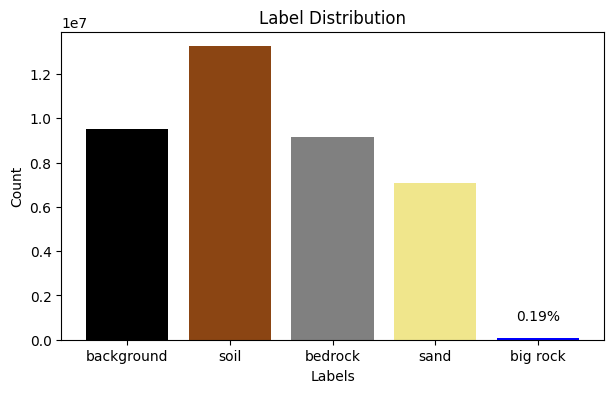

In [12]:
aug_labels = tf.concat(
    [
        tf.concat([labels for _, labels in train_dataset], axis=0),
        tf.concat([labels for _, labels in val_dataset], axis=0)
    ],
    axis=0
)

plot_distribution(aug_labels)

## 🛠️ Train and Save the Model

In [13]:
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable()
class InstanceNormalization(tf.keras.layers.Layer):
    def __init__(self, epsilon=1e-5, **kwargs):
        super(InstanceNormalization, self).__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        # Learnable scale and shift parameters
        self.gamma = self.add_weight(
            name="gamma",
            shape=(1, 1, 1, input_shape[-1]),
            initializer="ones",
            trainable=True,
        )
        self.beta = self.add_weight(
            name="beta",
            shape=(1, 1, 1, input_shape[-1]),
            initializer="zeros",
            trainable=True,
        )

    def call(self, inputs):
        mean, variance = tf.nn.moments(inputs, axes=[1, 2], keepdims=True)
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * normalized + self.beta

In [14]:
def enhanced_bottleneck(input_tensor, filters, name='bottleneck_', norm_type='batch'):
    """Enhanced bottleneck with parallel dilated convolutions, global context, and SE mechanism."""
    # Parallel dilated convolutions
    conv1 = tfkl.Conv2D(filters, kernel_size=3, dilation_rate=1, padding='same', activation='relu', name=name + 'dilated1')(input_tensor)
    conv2 = tfkl.Conv2D(filters, kernel_size=3, dilation_rate=2, padding='same', activation='relu', name=name + 'dilated2')(input_tensor)
    conv3 = tfkl.Conv2D(filters, kernel_size=3, dilation_rate=4, padding='same', activation='relu', name=name + 'dilated3')(input_tensor)

    if norm_type == 'batch':
        conv1 = tfkl.BatchNormalization(name=name + 'bn_dilated1')(conv1)
        conv2 = tfkl.BatchNormalization(name=name + 'bn_dilated2')(conv2)
        conv3 = tfkl.BatchNormalization(name=name + 'bn_dilated3')(conv3)
    elif norm_type == 'layer':
        conv1 = tfkl.LayerNormalization(name=name + 'ln_dilated1')(conv1)
        conv2 = tfkl.LayerNormalization(name=name + 'ln_dilated2')(conv2)
        conv3 = tfkl.LayerNormalization(name=name + 'ln_dilated3')(conv3)
    elif norm_type == 'instance':
        conv1 = InstanceNormalization(name=name + 'in_dilated1')(conv1)
        conv2 = InstanceNormalization(name=name + 'in_dilated2')(conv2)
        conv3 = InstanceNormalization(name=name + 'in_dilated3')(conv3)
        
    dilated_features = tfkl.Concatenate(name=name + 'concat_dilated')([conv1, conv2, conv3])

    # Global context module (e.g., pooling for global feature extraction)
    global_context = tfkl.GlobalAveragePooling2D(name=name + 'global_avg_pool')(dilated_features)
    global_context = tfkl.Dense(filters, activation='relu', name=name + 'gc_dense1')(global_context)
    global_context = tfkl.Dense(filters * 3, activation='sigmoid', name=name + 'gc_dense2')(global_context)
    global_context = tfkl.Reshape((1, 1, filters * 3), name=name + 'gc_reshape')(global_context)

    # Fuse global context with dilated features
    fused_features = tfkl.Multiply(name=name + 'fused')([dilated_features, global_context])

    # Squeeze-and-Excitation (SE) mechanism
    se = tfkl.GlobalAveragePooling2D(name=name + 'se_gap')(fused_features)
    se = tfkl.Dense(filters, activation='relu', name=name + 'se_dense1')(se)
    se = tfkl.Dense(filters * 3, activation='sigmoid', name=name + 'se_dense2')(se)
    se = tfkl.Reshape((1, 1, filters * 3), name=name + 'se_reshape')(se)
    se_features = tfkl.Multiply(name=name + 'se_scaled')([fused_features, se])

    # Final compression step to return reduced feature map
    compressed_features = tfkl.Conv2D(filters, kernel_size=1, activation='relu', name=name + 'compressed')(se_features)

    return compressed_features

# Add Gating to Skip Connections
def gated_skip_connection(encoder_features, decoder_features, filters, name):
    # Learn gating weights
    gate = tfkl.Conv2D(filters, kernel_size=1, activation='sigmoid', name=name + '_gate')(encoder_features)
    gated_features = tfkl.Multiply(name=name + '_gated')([encoder_features, gate])
    return tfkl.Concatenate(name=name + '_concat')([gated_features, decoder_features])

def unet_block(input_tensor, filters, kernel_size=3, activation='relu', stack=2, name='', norm_type='batch'):
    """Define a UNet block with configurable normalization."""
    x = input_tensor
    for i in range(stack):
        x = tfkl.Conv2D(filters, kernel_size=kernel_size, padding='same', name=name + f'conv{i+1}')(x)
        if norm_type == 'batch':
            x = tfkl.BatchNormalization(name=name + f'bn{i+1}')(x)
        elif norm_type == 'layer':
            x = tfkl.LayerNormalization(name=name + f'ln{i+1}')(x)
        elif norm_type == 'instance':
            x = InstanceNormalization(name=name + f'in{i+1}')(x)
 
        x = tfkl.Activation(activation, name=name + f'activation{i+1}')(x)
    x = tfkl.Dropout(0.5, name=name + 'dropout')(x)
    return x


def build_unet(input_tensor, num_classes, filters_base, name_prefix=''):
    """Define a single UNet with auxiliary outputs for deep supervision."""
    # Downsampling
    down_block_1 = unet_block(input_tensor, filters_base, name=name_prefix + 'down_block1_', norm_type='batch')
    d1 = tfkl.Conv2D(filters_base, kernel_size=3, strides=2, padding='same', activation='relu', name=name_prefix + 'downsample1')(down_block_1)
    
    down_block_2 = unet_block(d1, filters_base * 2, name=name_prefix + 'down_block2_', norm_type='layer')
    d2 = tfkl.Conv2D(filters_base * 2, kernel_size=3, strides=2, padding='same', activation='relu', name=name_prefix + 'downsample2')(d1)

    # Bottleneck
    bottleneck = enhanced_bottleneck(d2, filters_base * 4, name=name_prefix + 'bottleneck_', norm_type='instance')

    # Upsampling with intermediate outputs
    u1 = tfkl.Conv2DTranspose(filters_base * 2, kernel_size=3, strides=2, padding='same', activation='relu', name=name_prefix + 'upsample1')(bottleneck)
    u1 = gated_skip_connection(down_block_2, u1, filters_base * 2, name=name_prefix + 'skip1')    
    up_block_1 = unet_block(u1, filters_base * 2, name=name_prefix + 'up_block1_')
    aux_output_1 = tfkl.Conv2D(num_classes, kernel_size=1, activation='softmax', name=name_prefix + 'aux_out1')(up_block_1)

    u2 = tfkl.Conv2DTranspose(filters_base, kernel_size=3, strides=2, padding='same', activation='relu', name=name_prefix + 'upsample2')(up_block_1)
    u2 = gated_skip_connection(down_block_1, u2, filters_base, name=name_prefix + 'skip2')
    up_block_2 = unet_block(u2, filters_base, name=name_prefix + 'up_block2_')
    aux_output_2 = tfkl.Conv2D(num_classes, kernel_size=1, activation='softmax', name=name_prefix + 'aux_out2')(up_block_2)

    # Final output
    output = tfkl.Conv2D(num_classes, kernel_size=1, padding='same', activation='softmax', name=name_prefix + 'out')(up_block_2)

    return output, aux_output_1, aux_output_2

def get_double_unet(input_shape, num_classes=5, seed=42):
    """Define a double UNet model with hierarchical refinement."""
    tf.random.set_seed(seed)
    
    # Input layer
    input_layer = tfkl.Input(shape=input_shape, name='input_layer')
    
    # First UNet (Global Segmentation)
    global_output, global_aux1, global_aux2 = build_unet(input_layer, num_classes, filters_base=64, name_prefix='global_')
    
    # Concatenate global segmentation output back to the input for refinement
    global_output_conv = tfkl.Conv2D(input_shape[-1], kernel_size=1, padding='same', name='global_out_conv')(global_output)
    combined_input = tfkl.Concatenate(name='refinement_input')([input_layer, global_output_conv])
    
    # Second UNet (Local Segmentation)
    refined_output, refined_aux1, refined_aux2 = build_unet(combined_input, num_classes, filters_base=64, name_prefix='local_')

    # Model with only the final refined output
    model = tf.keras.Model(
        inputs=input_layer, 
        outputs=refined_output,  # Only return the refined output
        name='Double_UNet'
    )

    return model

ListWrapper(['local_out'])


Model: "Double_UNet"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer       │ (None, 64, 128, │         0 │ -              │   -   │
│ (InputLayer)      │ 1)              │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │       640 │ input_layer[0… │   Y   │
│ (Conv2D)          │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │       256 │ global_down_b… │   Y   │
│ (BatchNormalizat… │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │         0 │ global_down_b… │   -   │
│ (Activation)      │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │    36,928 │ global_down_b… │   Y   │
│ (Conv2D)          │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │       256 │ global_down_b… │   Y   │
│ (BatchNormalizat… │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │         0 │ global_down_b… │   -   │
│ (Activation)      │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │         0 │ global_down_b… │   -   │
│ (Dropout)         │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_downsampl… │ (None, 32, 64,  │    36,928 │ global_down_b… │   Y   │
│ (Conv2D)          │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_downsampl… │ (None, 16, 32,  │    73,856 │ global_downsa… │   Y   │
│ (Conv2D)          │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_bottlenec… │ (None, 16, 32,  │   295,168 │ global_downsa… │   Y   │
│ (Conv2D)          │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_bottlenec… │ (None, 16, 32,  │   295,168 │ global_downsa… │   Y   │
│ (Conv2D)          │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_bottlenec… │ (None, 16, 32,  │   295,168 │ global_downsa… │   Y   │
│ (Conv2D)          │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_bottlenec… │ (None, 16, 32,  │       512 │ global_bottle… │   Y   │
│ (InstanceNormali… │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_bottlenec… │ (None, 16, 32,  │       512 │ global_bottle… │   Y   │
│ (InstanceNormali… │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_bottlenec… │ (None, 16, 32,  │       512 │ global_bottle… │   Y   │
│ (InstanceNormali… │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_bottlenec… │ (None, 16, 32,  │         0 │ global_bottle… │   - 

 Total params: 6,376,400 (24.32 MB)

 Trainable params: 6,374,352 (24.32 MB)

 Non-trainable params: 2,048 (8.00 KB)

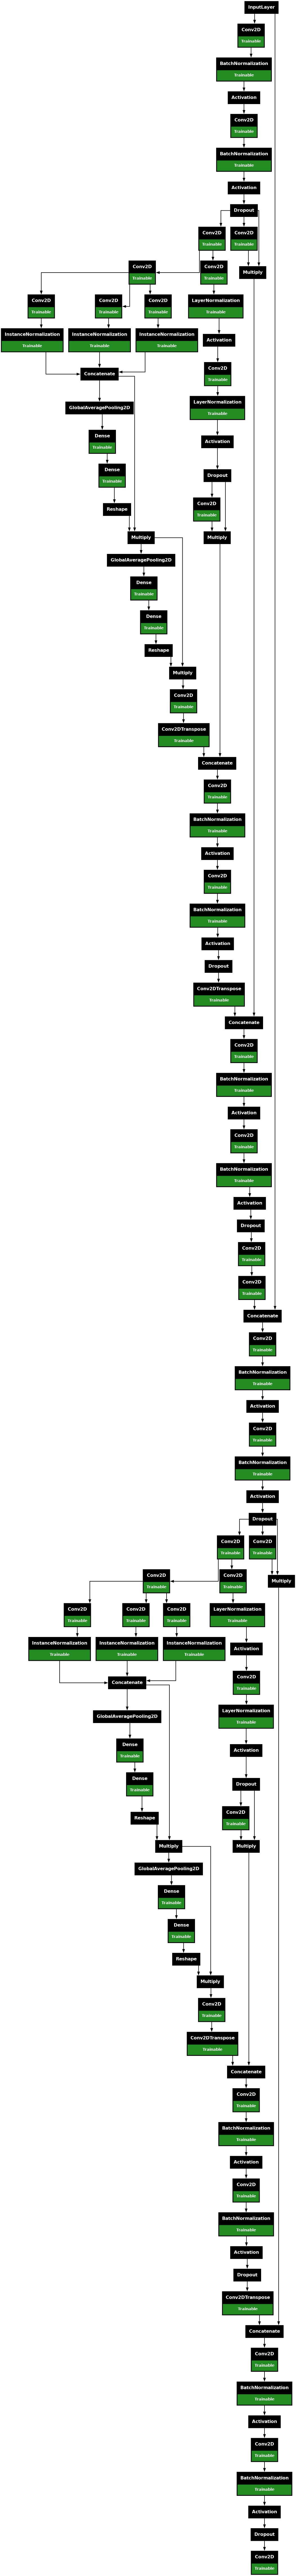

In [15]:
model = get_double_unet(input_shape=input_shape)

print(model.output_names)
model.summary(expand_nested=True, show_trainable=True)
tf.keras.utils.plot_model(model, to_file='/kaggle/working/model.png', show_trainable=True, expand_nested=True, dpi=70)

In [16]:
class VizCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_dataset, frequency, n):
        super().__init__()
        self.val_dataset = val_dataset  # Take the validation dataset
        self.frequency = frequency
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.frequency == 0:  # Visualize only every "frequency" epochs
            # Extract a batch from the validation dataset
            val_batch = next(iter(self.val_dataset))  # Take one batch
            images, labels = val_batch  # Unbatch the data
            n = min(self.n, len(images))  # Ensure we don't exceed available images
            
            preds = self.model.predict(images, verbose=0)
            #print("\n 1 pixel prediction:", preds[0][0][0])
            y_preds = tf.math.argmax(preds, axis=-1).numpy()  # Convert predictions to numpy
            #print("1 pixel prediction argmax:", y_preds[0][0][0])

            # Determine rows and columns for plotting
            rows = (n + 1) // 2  # Calculate rows needed for 2 images per row
            plt.figure(figsize=(12, rows))  # Adjust figure size for rows

            for i in range(n):
                col = (i % 2) * 3  # Columns in each row (3 subplots per image)
                row = i // 2       # Current row

                # Input image
                plt.subplot(rows, 6, row * 6 + col + 1)
                plt.imshow(images[i], cmap='gray', vmin=0, vmax=1)
                plt.title(f"Input {i + 1}")
                plt.axis('off')

                # Ground truth
                plt.subplot(rows, 6, row * 6 + col + 2)
                plt.imshow(labels[i], cmap=cmap, vmin=0, vmax=4)
                plt.title(f"Ground Truth {i + 1}")
                plt.axis('off')

                # Prediction
                plt.subplot(rows, 6, row * 6 + col + 3)
                plt.imshow(y_preds[i], cmap=cmap, vmin=0, vmax=4)
                plt.title(f"Prediction {i + 1}")
                plt.axis('off')

            plt.tight_layout()
            plt.show()
            plt.close()

In [17]:
from tensorflow.keras import backend as K

# Multi-Class Dice Loss
@register_keras_serializable()
def multi_class_dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Multi-Class Dice Loss function.

    Parameters:
    y_true (tensor): Ground truth labels (one-hot encoded).
    y_pred (tensor): Predicted labels (probabilities, not one-hot encoded).
    smooth (float): Smoothing factor to avoid division by zero.

    Returns:
    tensor: Multi-Class Dice Loss.
    """
    # Convert y_true to one-hot encoding if not already one-hot encoded
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])

    # Number of classes
    num_classes = K.int_shape(y_pred)[-1]

    # Initialize the loss
    loss = 0

    # Calculate the loss for each class
    for i in range(num_classes):
        y_true_class = y_true[..., i]
        y_pred_class = y_pred[..., i]

        # Flatten the tensors to apply the loss function
        y_true_class = tf.reshape(y_true_class, [-1])
        y_pred_class = tf.reshape(y_pred_class, [-1])

        # Calculate Dice Coefficient for this class
        intersection = tf.reduce_sum(y_true_class * y_pred_class)
        union = tf.reduce_sum(y_true_class) + tf.reduce_sum(y_pred_class)
        
        # Calculate Dice Loss
        dice = (2. * intersection + smooth) / (union + smooth)
        dice_loss = 1 - dice

        # Add the loss for this class to the total loss
        loss += dice_loss

    # Average the loss across all classes
    loss /= num_classes

    return loss

@register_keras_serializable()
def combined_loss(y_true, y_pred):
    ce_loss = tf.keras.losses.SparseCategoricalCrossentropy()(y_true, y_pred)
    dice_loss_value = multi_class_dice_loss(y_true, y_pred)
    return ce_loss + dice_loss_value

Model compiled!
Epoch 1/1000


I0000 00:00:1734207974.688938      69 service.cc:145] XLA service 0x7ed7d800ade0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1734207974.689022      69 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1734207974.689028      69 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
W0000 00:00:1734207975.647860      69 assert_op.cc:38] Ignoring Assert operator compile_loss/combined_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1734208067.527072      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     69/Unknown 131s 241ms/step - accuracy: 0.3624 - loss: 1.9494 - mean_iou: 0.1608

W0000 00:00:1734208085.047187      69 assert_op.cc:38] Ignoring Assert operator compile_loss/combined_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


     70/Unknown 211s 1s/step - accuracy: 0.3639 - loss: 1.9454 - mean_iou: 0.1618   

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
W0000 00:00:1734208166.735742      67 assert_op.cc:38] Ignoring Assert operator compile_loss/combined_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1734208169.224408      68 assert_op.cc:38] Ignoring Assert operator compile_loss/combined_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


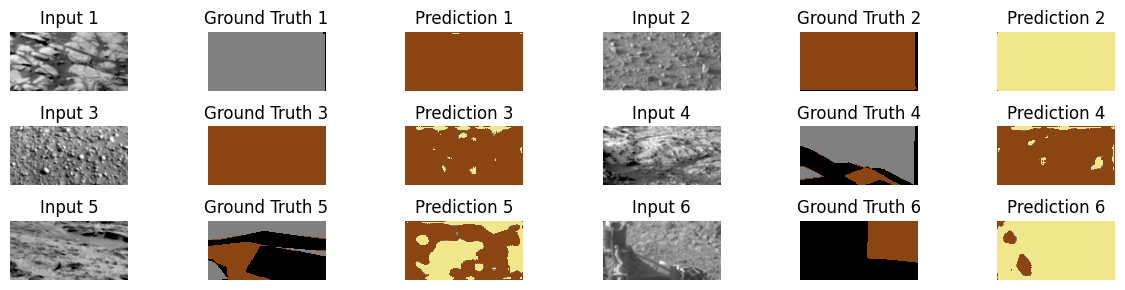

70/70 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.3654 - loss: 1.9416 - mean_iou: 0.1628 - val_accuracy: 0.3043 - val_loss: 3.1806 - val_mean_iou: 0.1130 - learning_rate: 0.0010
Epoch 2/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 269ms/step - accuracy: 0.5983 - loss: 1.3711 - mean_iou: 0.3370 - val_accuracy: 0.2748 - val_loss: 3.0428 - val_mean_iou: 0.1302 - learning_rate: 0.0010
Epoch 3/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 261ms/step - accuracy: 0.6343 - loss: 1.2786 - mean_iou: 0.3590 - val_accuracy: 0.2117 - val_loss: 4.1199 - val_mean_iou: 0.0737 - learning_rate: 0.0010
Epoch 4/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.6542 - loss: 1.2275 - mean_iou: 0.3751 - val_accuracy: 0.2178 - val_loss: 4.1533 - val_mean_iou: 0.0577 - learning_rate: 0.0010
Epoch 5/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.6621 - loss: 1.1942 - mean_iou: 0.3822 - val_accuracy: 0.2930 - val_loss: 3.2424 - val_mean_iou: 0.0985 - learning_rate: 0.0010
Epoch 6/1000
70/70 ━━━━━━━━━━━

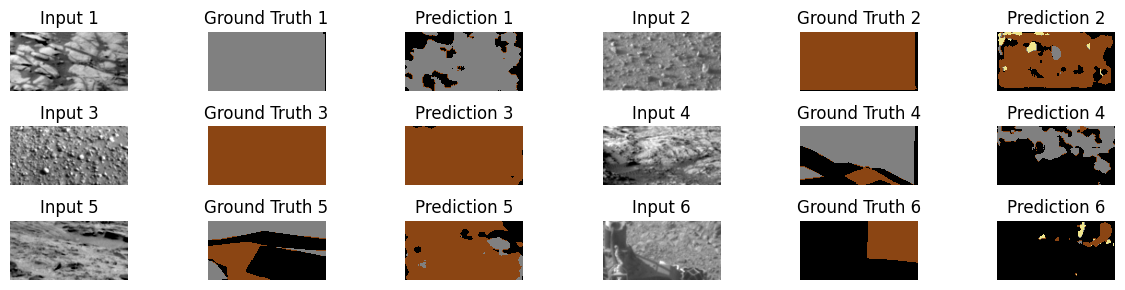

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 275ms/step - accuracy: 0.7187 - loss: 1.0374 - mean_iou: 0.4348 - val_accuracy: 0.5667 - val_loss: 1.7917 - val_mean_iou: 0.2561 - learning_rate: 0.0010
Epoch 12/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 259ms/step - accuracy: 0.7237 - loss: 1.0284 - mean_iou: 0.4378 - val_accuracy: 0.5938 - val_loss: 1.6808 - val_mean_iou: 0.2903 - learning_rate: 0.0010
Epoch 13/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 259ms/step - accuracy: 0.7239 - loss: 1.0281 - mean_iou: 0.4336 - val_accuracy: 0.7038 - val_loss: 1.3386 - val_mean_iou: 0.3984 - learning_rate: 0.0010
Epoch 14/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.7372 - loss: 0.9916 - mean_iou: 0.4470 - val_accuracy: 0.6588 - val_loss: 1.5258 - val_mean_iou: 0.3479 - learning_rate: 0.0010
Epoch 15/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.7482 - loss: 0.9557 - mean_iou: 0.4609 - val_accuracy: 0.6656 - val_loss: 1.4550 - val_mean_iou: 0.3577 - learning_rate: 0.0010
Epoch 16/1000
70/70 ━━━━

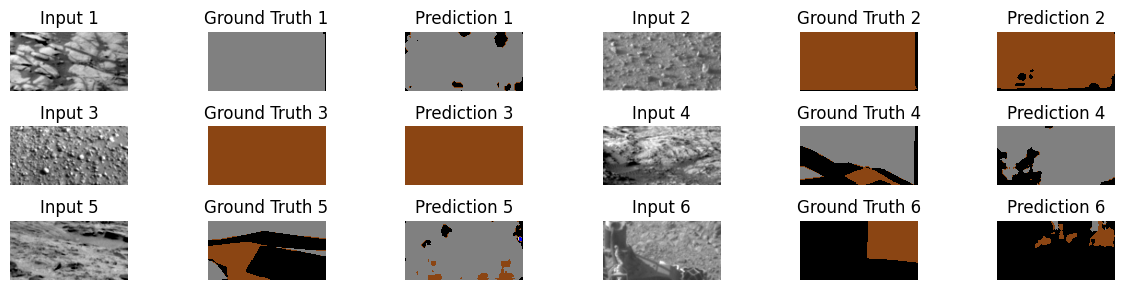

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 272ms/step - accuracy: 0.7836 - loss: 0.8487 - mean_iou: 0.4928 - val_accuracy: 0.6831 - val_loss: 1.4320 - val_mean_iou: 0.3786 - learning_rate: 0.0010
Epoch 22/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.7898 - loss: 0.8276 - mean_iou: 0.5034 - val_accuracy: 0.6746 - val_loss: 1.4315 - val_mean_iou: 0.3745 - learning_rate: 0.0010
Epoch 23/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.7948 - loss: 0.8131 - mean_iou: 0.5070 - val_accuracy: 0.6948 - val_loss: 1.4191 - val_mean_iou: 0.3854 - learning_rate: 0.0010
Epoch 24/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.8039 - loss: 0.7816 - mean_iou: 0.5232 - val_accuracy: 0.7121 - val_loss: 1.3345 - val_mean_iou: 0.4124 - learning_rate: 0.0010
Epoch 25/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.8125 - loss: 0.7483 - mean_iou: 0.5415 - val_accuracy: 0.6612 - val_loss: 1.5396 - val_mean_iou: 0.3731 - learning_rate: 0.0010
Epoch 26/1000
70/70 ━━━━

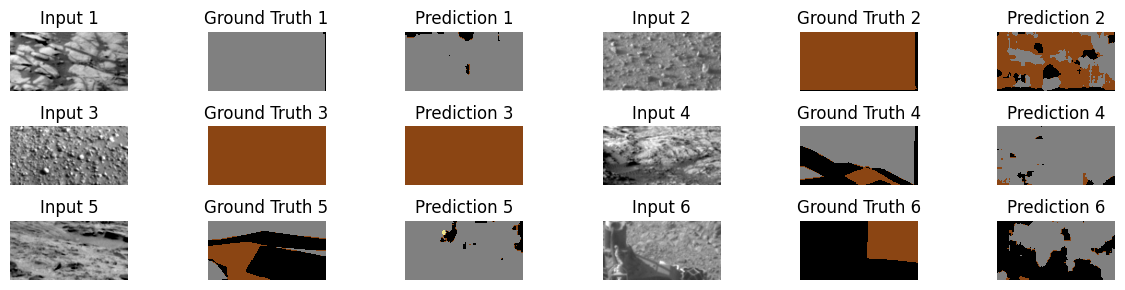

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.8495 - loss: 0.6029 - mean_iou: 0.6430 - val_accuracy: 0.6531 - val_loss: 1.7153 - val_mean_iou: 0.3603 - learning_rate: 0.0010
Epoch 32/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.8408 - loss: 0.6330 - mean_iou: 0.6225 - val_accuracy: 0.7003 - val_loss: 1.4582 - val_mean_iou: 0.4000 - learning_rate: 0.0010
Epoch 33/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.8564 - loss: 0.5714 - mean_iou: 0.6536 - val_accuracy: 0.6981 - val_loss: 1.4806 - val_mean_iou: 0.4048 - learning_rate: 0.0010
Epoch 34/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.8685 - loss: 0.5358 - mean_iou: 0.6582 - val_accuracy: 0.6975 - val_loss: 1.5201 - val_mean_iou: 0.3984 - learning_rate: 0.0010
Epoch 35/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.8688 - loss: 0.5388 - mean_iou: 0.6597 - val_accuracy: 0.6805 - val_loss: 1.6501 - val_mean_iou: 0.3783 - learning_rate: 0.0010
Epoch 36/1000
70/70 ━━━━

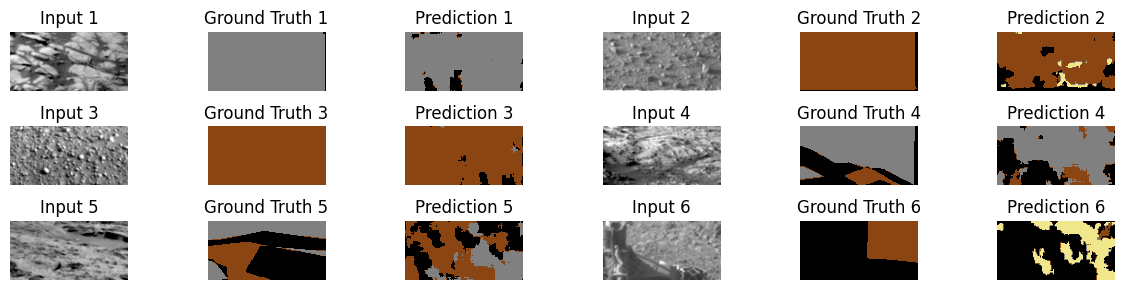

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 276ms/step - accuracy: 0.9117 - loss: 0.3928 - mean_iou: 0.7076 - val_accuracy: 0.5976 - val_loss: 2.2626 - val_mean_iou: 0.2990 - learning_rate: 5.0000e-04
Epoch 42/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9189 - loss: 0.3626 - mean_iou: 0.7133 - val_accuracy: 0.6436 - val_loss: 2.0158 - val_mean_iou: 0.3408 - learning_rate: 5.0000e-04
Epoch 43/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9182 - loss: 0.3713 - mean_iou: 0.7051 - val_accuracy: 0.6623 - val_loss: 1.8956 - val_mean_iou: 0.3557 - learning_rate: 5.0000e-04
Epoch 44/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.9198 - loss: 0.3550 - mean_iou: 0.7098 - val_accuracy: 0.6382 - val_loss: 2.0432 - val_mean_iou: 0.3253 - learning_rate: 5.0000e-04
Epoch 45/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.9228 - loss: 0.3626 - mean_iou: 0.7058 - val_accuracy: 0.6699 - val_loss: 1.8550 - val_mean_iou: 0.3648 - learning_rate: 5.0000e-04
Epoc

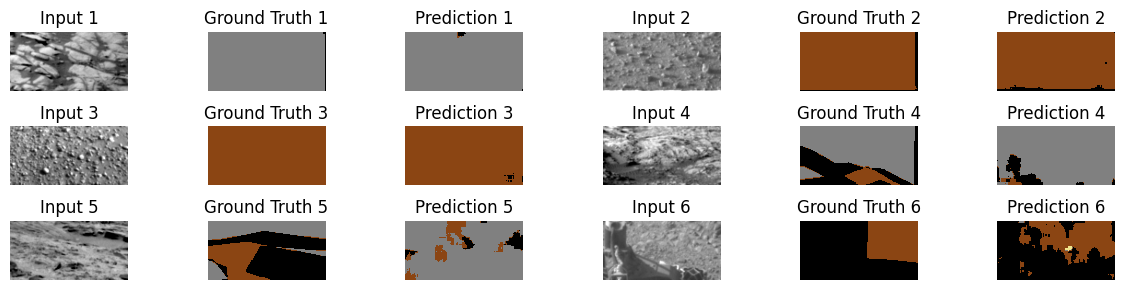

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.9379 - loss: 0.3025 - mean_iou: 0.7224 - val_accuracy: 0.7119 - val_loss: 1.7142 - val_mean_iou: 0.4182 - learning_rate: 2.5000e-04
Epoch 52/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.9390 - loss: 0.2865 - mean_iou: 0.7276 - val_accuracy: 0.6967 - val_loss: 1.8509 - val_mean_iou: 0.3951 - learning_rate: 2.5000e-04
Epoch 53/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9417 - loss: 0.2868 - mean_iou: 0.7241 - val_accuracy: 0.7016 - val_loss: 1.8068 - val_mean_iou: 0.4084 - learning_rate: 2.5000e-04
Epoch 54/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.9418 - loss: 0.2763 - mean_iou: 0.7318 - val_accuracy: 0.7192 - val_loss: 1.7012 - val_mean_iou: 0.4248 - learning_rate: 2.5000e-04
Epoch 55/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.9447 - loss: 0.2633 - mean_iou: 0.7325 - val_accuracy: 0.7190 - val_loss: 1.7120 - val_mean_iou: 0.4277 - learning_rate: 2.5000e-04
Epoc

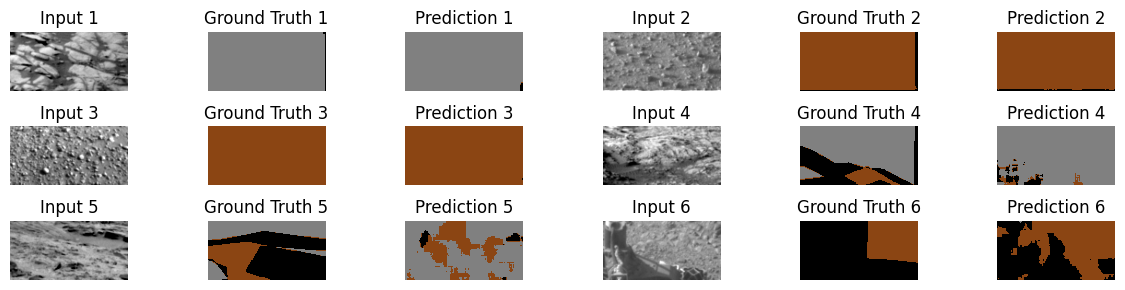

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.9501 - loss: 0.2417 - mean_iou: 0.7366 - val_accuracy: 0.7303 - val_loss: 1.7657 - val_mean_iou: 0.4350 - learning_rate: 1.2500e-04
Epoch 62/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.9501 - loss: 0.2559 - mean_iou: 0.7397 - val_accuracy: 0.7280 - val_loss: 1.7764 - val_mean_iou: 0.4343 - learning_rate: 1.2500e-04
Epoch 63/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9506 - loss: 0.2393 - mean_iou: 0.7394 - val_accuracy: 0.7293 - val_loss: 1.7741 - val_mean_iou: 0.4357 - learning_rate: 1.2500e-04
Epoch 64/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9517 - loss: 0.2399 - mean_iou: 0.7405 - val_accuracy: 0.7287 - val_loss: 1.7853 - val_mean_iou: 0.4350 - learning_rate: 1.2500e-04
Epoch 65/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9518 - loss: 0.2353 - mean_iou: 0.7420 - val_accuracy: 0.7301 - val_loss: 1.7975 - val_mean_iou: 0.4336 - learning_rate: 1.2500e-04
Epoc

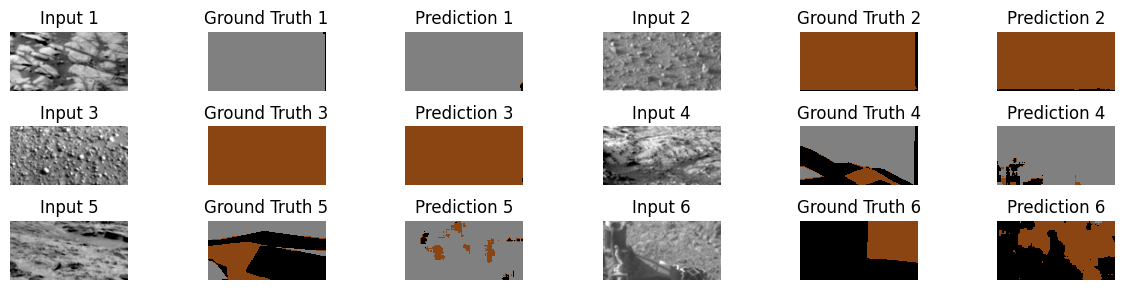

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 270ms/step - accuracy: 0.9550 - loss: 0.2254 - mean_iou: 0.7440 - val_accuracy: 0.7316 - val_loss: 1.7535 - val_mean_iou: 0.4391 - learning_rate: 1.2500e-04
Epoch 72/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9551 - loss: 0.2435 - mean_iou: 0.7444
Epoch 72: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.9551 - loss: 0.2434 - mean_iou: 0.7442 - val_accuracy: 0.7352 - val_loss: 1.7326 - val_mean_iou: 0.4428 - learning_rate: 1.2500e-04
Epoch 73/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.9562 - loss: 0.2352 - mean_iou: 0.7455 - val_accuracy: 0.7354 - val_loss: 1.7389 - val_mean_iou: 0.4401 - learning_rate: 6.2500e-05
Epoch 74/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9558 - loss: 0.2261 - mean_iou: 0.7421 - val_accuracy: 0.7392 - val_loss: 1.6942 - val_mean_iou: 0.4458 - learning_rate: 6.2500e-05
Epoch 75/1000
70/70 ━━━━━━━━━━━━━━━━

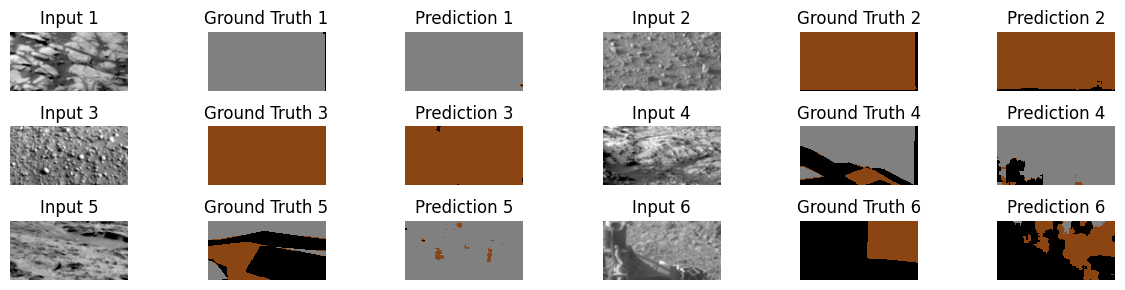

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 270ms/step - accuracy: 0.9583 - loss: 0.2152 - mean_iou: 0.7478 - val_accuracy: 0.7385 - val_loss: 1.7109 - val_mean_iou: 0.4440 - learning_rate: 6.2500e-05
Epoch 82/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9592 - loss: 0.2066 - mean_iou: 0.7483 - val_accuracy: 0.7406 - val_loss: 1.7305 - val_mean_iou: 0.4460 - learning_rate: 6.2500e-05
Epoch 83/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9598 - loss: 0.2067 - mean_iou: 0.7459 - val_accuracy: 0.7400 - val_loss: 1.7167 - val_mean_iou: 0.4465 - learning_rate: 6.2500e-05
Epoch 84/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9600 - loss: 0.2026 - mean_iou: 0.7496
Epoch 84: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9600 - loss: 0.2028 - mean_iou: 0.7495 - val_accuracy: 0.7370 - val_loss: 1.7233 - val_mean_iou: 0.4454 - learning_rate: 6.2500e-05
Epoch 85/1000
70/70 ━━━━━━━━━━━━━━━

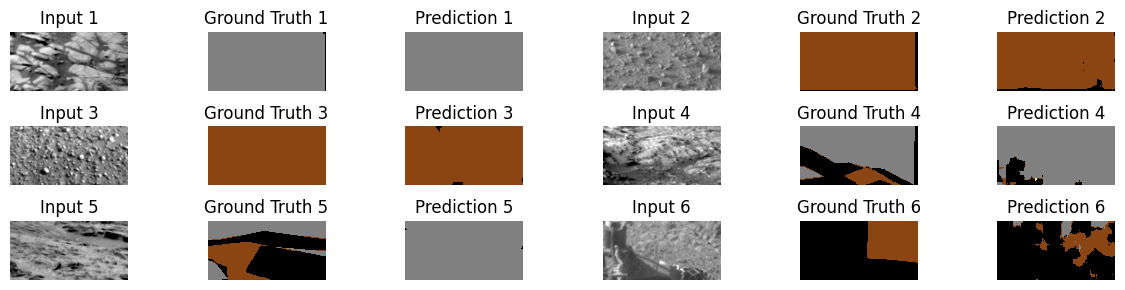

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 270ms/step - accuracy: 0.9614 - loss: 0.1996 - mean_iou: 0.7512 - val_accuracy: 0.7319 - val_loss: 1.7378 - val_mean_iou: 0.4389 - learning_rate: 3.1250e-05
Epoch 92/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.9605 - loss: 0.1957 - mean_iou: 0.7514 - val_accuracy: 0.7298 - val_loss: 1.7441 - val_mean_iou: 0.4363 - learning_rate: 3.1250e-05
Epoch 93/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.9612 - loss: 0.2048 - mean_iou: 0.7508 - val_accuracy: 0.7322 - val_loss: 1.7376 - val_mean_iou: 0.4388 - learning_rate: 3.1250e-05
Epoch 94/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9619 - loss: 0.1998 - mean_iou: 0.7507 - val_accuracy: 0.7301 - val_loss: 1.7439 - val_mean_iou: 0.4372 - learning_rate: 3.1250e-05
Epoch 95/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9619 - loss: 0.2111 - mean_iou: 0.7464 - val_accuracy: 0.7294 - val_loss: 1.7476 - val_mean_iou: 0.4368 - learning_rate: 3.1250e-05
Epoc

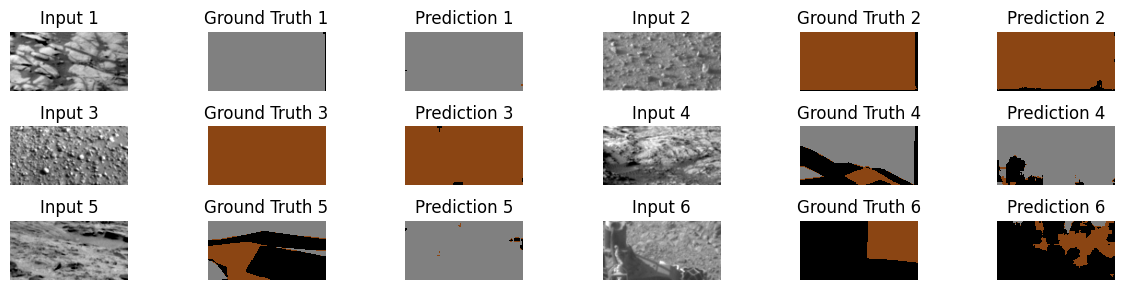

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 277ms/step - accuracy: 0.9626 - loss: 0.1916 - mean_iou: 0.7532 - val_accuracy: 0.7304 - val_loss: 1.7537 - val_mean_iou: 0.4354 - learning_rate: 1.5625e-05
Epoch 102/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.9620 - loss: 0.2012 - mean_iou: 0.7527 - val_accuracy: 0.7298 - val_loss: 1.7616 - val_mean_iou: 0.4338 - learning_rate: 1.5625e-05
Epoch 103/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.9631 - loss: 0.2048 - mean_iou: 0.7503 - val_accuracy: 0.7310 - val_loss: 1.7575 - val_mean_iou: 0.4349 - learning_rate: 1.5625e-05
Epoch 104/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.9627 - loss: 0.1957 - mean_iou: 0.7532 - val_accuracy: 0.7297 - val_loss: 1.7603 - val_mean_iou: 0.4344 - learning_rate: 1.5625e-05
Epoch 105/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.9627 - loss: 0.2037 - mean_iou: 0.7522 - val_accuracy: 0.7317 - val_loss: 1.7559 - val_mean_iou: 0.4360 - learning_rate: 1.5625e-05


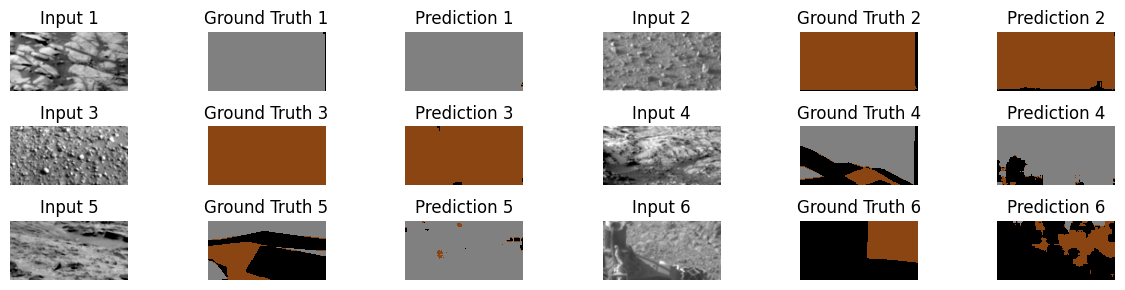

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.9639 - loss: 0.1904 - mean_iou: 0.7535 - val_accuracy: 0.7307 - val_loss: 1.7639 - val_mean_iou: 0.4345 - learning_rate: 1.0000e-05
Epoch 112/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.9641 - loss: 0.1907 - mean_iou: 0.7538 - val_accuracy: 0.7305 - val_loss: 1.7662 - val_mean_iou: 0.4343 - learning_rate: 1.0000e-05
Epoch 113/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 254ms/step - accuracy: 0.9632 - loss: 0.2106 - mean_iou: 0.7457 - val_accuracy: 0.7319 - val_loss: 1.7647 - val_mean_iou: 0.4356 - learning_rate: 1.0000e-05
Final validation Mean Intersection Over Union: 44.65%


In [18]:
mean_iou = tfk.metrics.MeanIoU(num_classes=5, ignore_class=0, sparse_y_pred=False, name='mean_iou')

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE),
    loss=combined_loss,
    metrics=['accuracy', mean_iou]
)
print("Model compiled!")


# Setup callbacks, should focus on the best val_mean_iou, more relevant than the loss since it is our target
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_mean_iou',
    patience=PATIENCE,
    restore_best_weights=True
)

# Usage, should focus on loss, less noisy than mean_iou
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=12, min_lr=1e-5, verbose=1
)

n = 6 # Number of images to visualize
viz_callback = VizCallback(val_dataset, frequency=10, n=n)

# Train the model
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[lr_scheduler, early_stopping, viz_callback],
    verbose=1,
    class_weight=class_weights_dict
).history

# Calculate and print the final validation accuracy
final_val_meanIoU = round(max(history['val_mean_iou'])* 100, 2)
print(f'Final validation Mean Intersection Over Union: {final_val_meanIoU}%')

In [19]:
model_filename = f'Super_Double_UNet_{str(final_val_meanIoU)}_aug5.keras'

if (on_kaggle):
    model_filename = f"/kaggle/working/{model_filename}"

model.save(model_filename)
print(f"Model saved to {model_filename}")

Model saved to /kaggle/working/Super_Double_UNet_44.65_aug5.keras


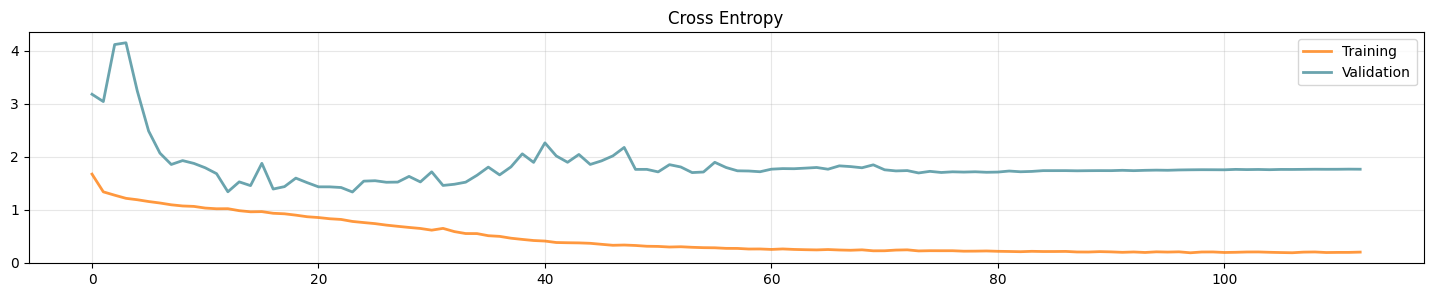

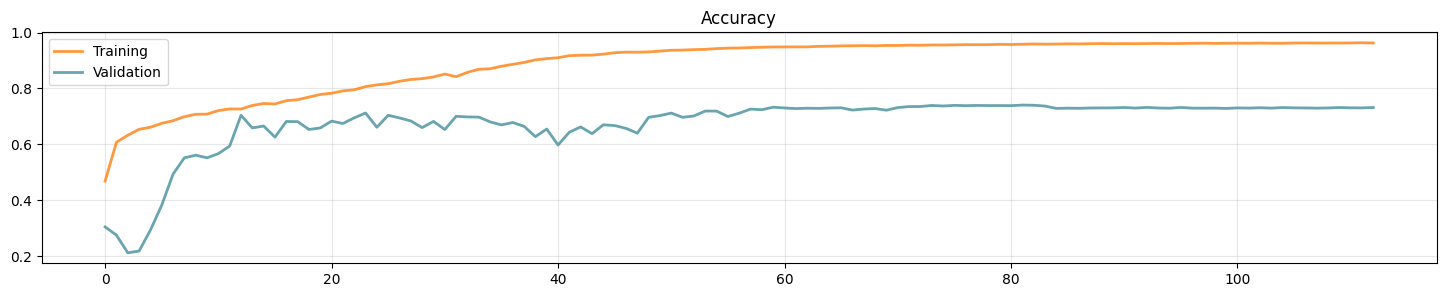

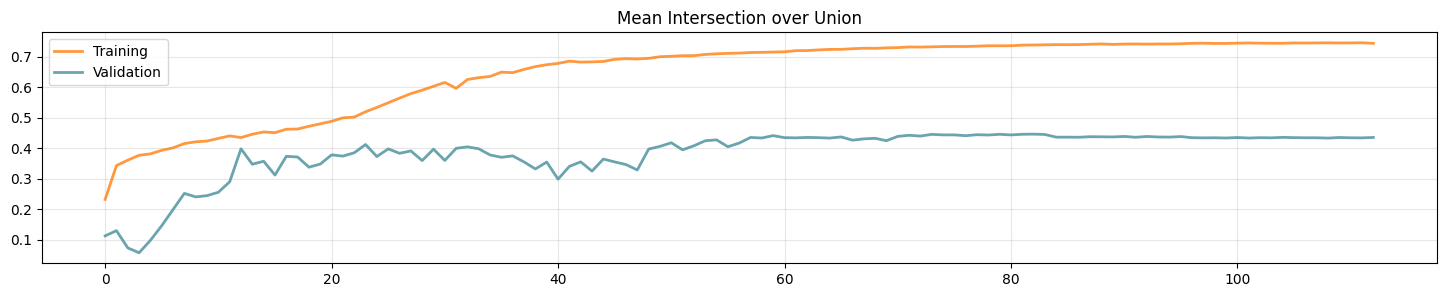

In [20]:
plt.figure(figsize=(18, 3))
plt.plot(history['loss'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_loss'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Cross Entropy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(18, 3))
plt.plot(history['accuracy'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_accuracy'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(18, 3))
plt.plot(history['mean_iou'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_mean_iou'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Mean Intersection over Union')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 📊 Prepare Your Submission

In our Kaggle competition, submissions are made as `csv` files. To create a proper `csv` file, you need to flatten your predictions and include an `id` column as the first column of your dataframe. To maintain consistency between your results and our solution, please avoid shuffling the test set. The code below demonstrates how to prepare the `csv` file from your model predictions.



Model loaded from /kaggle/working/Super_Double_UNet_44.65_aug5.keras
314/314 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step
Predictions shape: (10022, 64, 128)
Class counts: [20631462 25462291 22929154 13068475     8842]


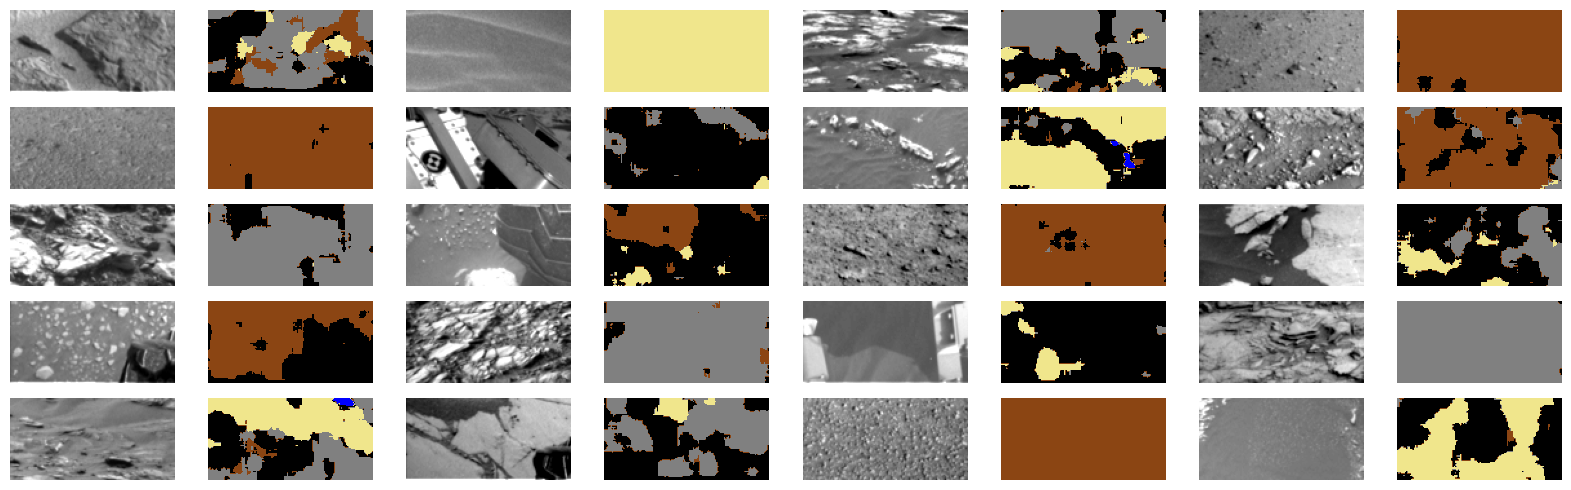

In [21]:
model_pred = tfk.models.load_model(
    model_filename,
    custom_objects={
        "InstanceNormalization": InstanceNormalization,
        'loss_fn': combined_loss
    })
print(f"Model loaded from {model_filename}")

X_test = apply_preprocessing(X_test_original) 
X_test = tf.cast(X_test, tf.float32)

preds = model_pred.predict(X_test)
preds = np.argmax(preds, axis=-1)
class_counts = np.bincount(preds.flatten(), minlength=5)

print(f"Predictions shape: {preds.shape}")
print(f"Class counts: {class_counts}")
plot_image_label(X_test, preds, 5, 4, 1)

In [22]:
def y_to_df(y) -> pd.DataFrame:
    n_samples = len(y)
    y_flat = y.reshape(n_samples, -1)
    df = pd.DataFrame(y_flat)
    df["id"] = np.arange(n_samples)
    cols = ["id"] + [col for col in df.columns if col != "id"]
    return df[cols]

submission_df = y_to_df(preds)
submission_filename = model_filename.replace(".keras", ".csv")
zip_filename = model_filename.replace(".keras", ".zip")
submission_df.to_csv(submission_filename, index=False)

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    filename = submission_filename.replace("/kaggle/working/", "")
    zipf.write(submission_filename, arcname=filename)

os.remove(submission_filename)
print("Zip file with CSV created successfully!")

Zip file with CSV created successfully!
